In [8]:
# 1. Data Loading and Initial Exploration

import pandas as pd

# Load the dataset (adapt to your actual file path if needed)
df = pd.read_csv('/Users/sam/Documents/DI_DATA_2025/week12/Apple Stock Prices (1981 to 2023).csv')

# Convert 'Date' column to datetime (day comes first!)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Set 'Date' as index for time series operations
df.set_index('Date', inplace=True)

# Display first rows to check everything looks good
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_42295/3830085683.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['Close'].resample('M').mean()


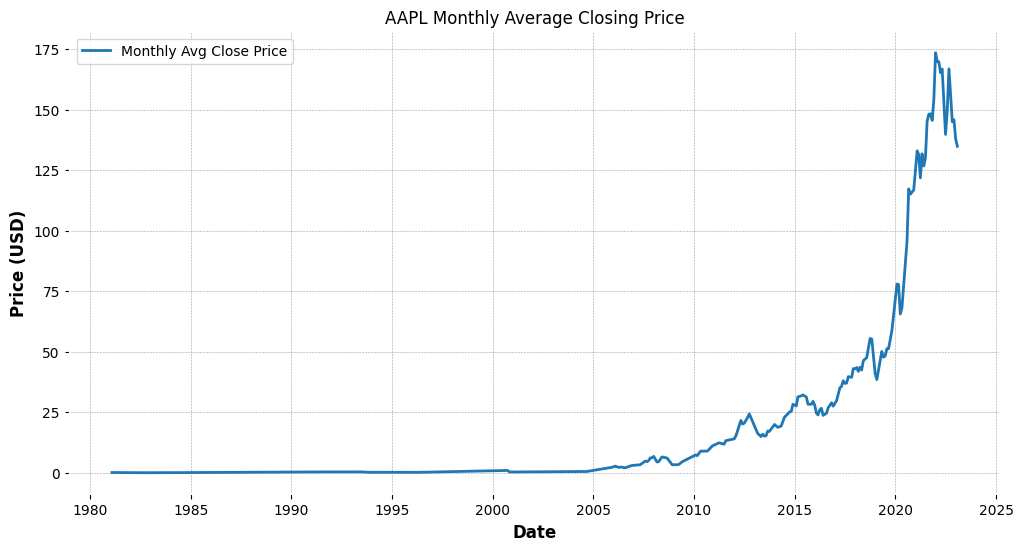

In [14]:
#2.Data Visualization
# Monthly average of closing price
monthly_avg = df['Close'].resample('M').mean()

# Plot trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_avg, label='Monthly Avg Close Price')
plt.title('AAPL Monthly Average Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

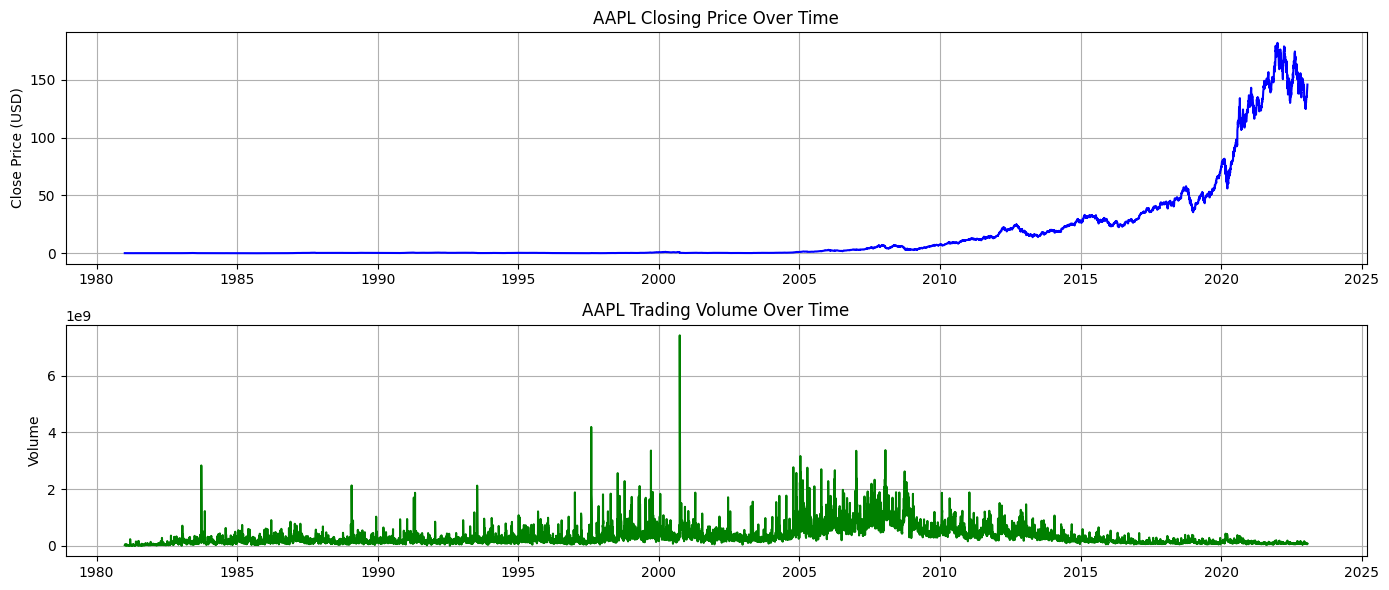

In [10]:
# Plot closing price and traded volume over time
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Closing price
plt.subplot(2,1,1)
plt.plot(df['Close'], color='blue')
plt.title('AAPL Closing Price Over Time')
plt.ylabel('Close Price (USD)')
plt.grid(True)

# Volume
plt.subplot(2,1,2)
plt.plot(df['Volume'], color='green')
plt.title('AAPL Trading Volume Over Time')
plt.ylabel('Volume')
plt.grid(True)

plt.tight_layout()
plt.show()


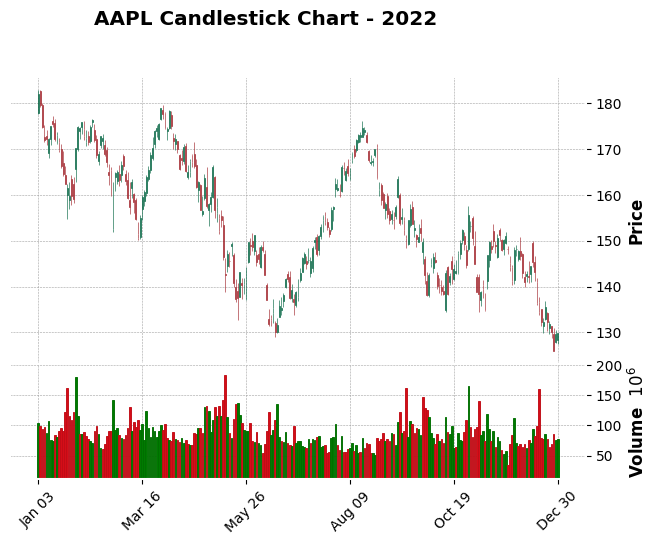

In [13]:
import mplfinance as mpf

# Select data for candlestick chart (e.g., full year 2022)
candlestick_data = df.loc['2022-01-01':'2022-12-31']

# Plot candlestick chart with volume
mpf.plot(candlestick_data, type='candle', style='charles', volume=True, title='AAPL Candlestick Chart - 2022')


In [15]:
#3 Statistical Analysis
# Descriptive statistics of key financial columns
df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].describe()


,Open,High,Low,Close,Adj Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


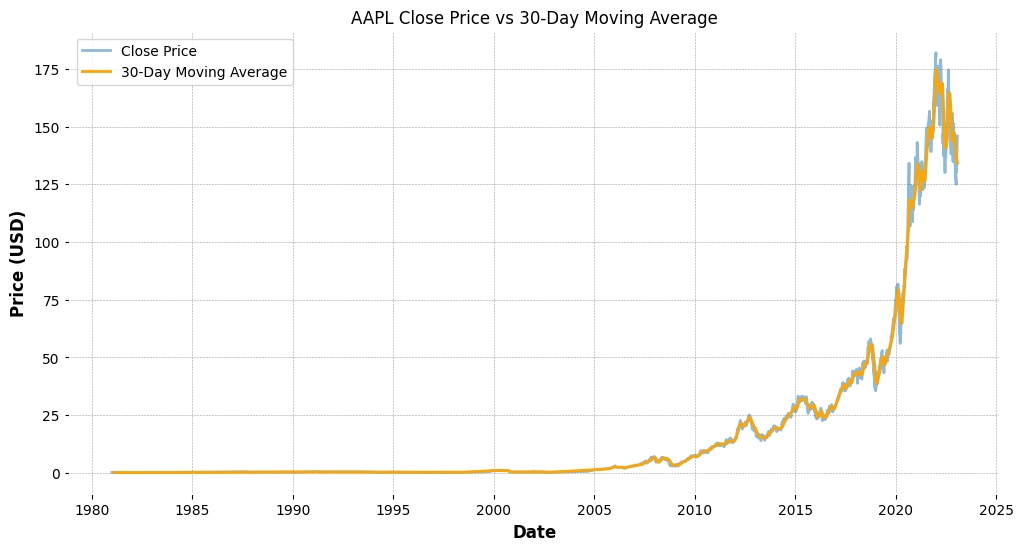

In [16]:
# Calculate 30-day moving average of the closing price
df['MA30'] = df['Close'].rolling(window=30).mean()

# Plot the original closing price and the 30-day moving average
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price', alpha=0.5)
plt.plot(df['MA30'], label='30-Day Moving Average', color='orange')
plt.title('AAPL Close Price vs 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
#4 Hypothesis Testing
# Create a 'Year' column from the datetime index
df['Year'] = df.index.year

# Calculate average closing price per year
annual_avg = df.groupby('Year')['Close'].mean()
annual_avg.tail()


Year
2019     52.063988
2020     95.347075
2021    140.989365
2022    154.835060
2023    134.905000
Name: Close, dtype: float64

In [18]:
from scipy.stats import ttest_ind

# Select data for two specific years
year_2020 = df[df['Year'] == 2020]['Close']
year_2022 = df[df['Year'] == 2022]['Close']

# Perform independent t-test (Welch's t-test)
t_stat, p_value = ttest_ind(year_2020.dropna(), year_2022.dropna(), equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")


T-statistic: -37.1855
P-value: 0.0000


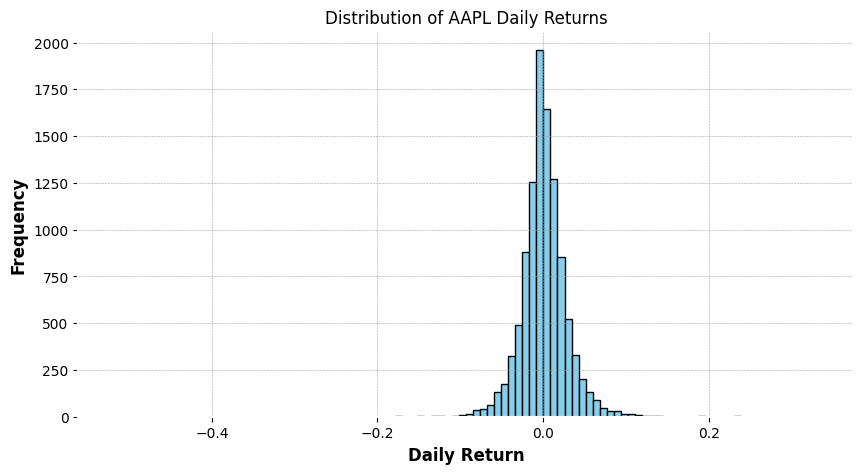

In [19]:
# Calculate daily returns
df['Daily Return'] = df['Close'].pct_change()

# Histogram of daily returns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['Daily Return'].dropna(), bins=100, color='skyblue', edgecolor='black')
plt.title('Distribution of AAPL Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [20]:
from scipy.stats import normaltest

# Drop NaNs for test
returns = df['Daily Return'].dropna()

# Perform D’Agostino and Pearson’s test for normality
stat, p = normaltest(returns)

print(f"Normality test statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

Normality test statistic: 2719.2053
P-value: 0.0000


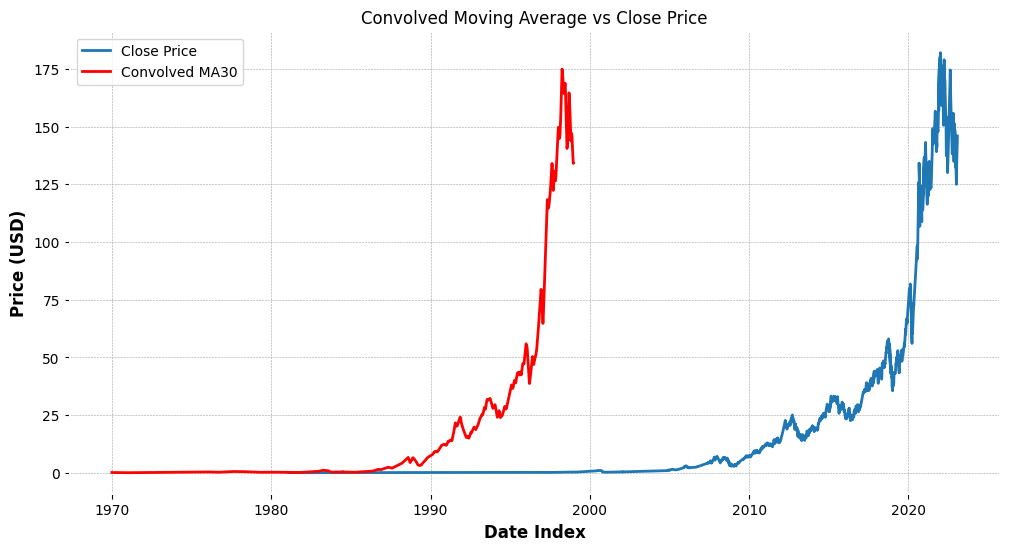

In [21]:
#5. Advanced Statistical Techniques (bonus)
#A.Signal Processing using SciPy
import numpy as np

# Create a convolution kernel for a 30-day moving average
kernel = np.ones(30) / 30

# Use np.convolve with 'valid' mode to calculate moving average
convolved_ma = np.convolve(df['Close'], kernel, mode='valid')

# Plot original closing price vs convolved moving average
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'][29:], label='Close Price')
plt.plot(convolved_ma, label='Convolved MA30', color='red')
plt.title('Convolved Moving Average vs Close Price')
plt.xlabel('Date Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
#B. Statiscal functions in numpy
# Compute 30-day moving average of Close price
ma30 = df['Close'].rolling(window=30).mean()

# Extract the Volume column
volume = df['Volume']

# Remove NaN values for both series to align lengths
valid_idx = ~ma30.isna()
ma30_clean = ma30[valid_idx]
volume_clean = volume[valid_idx]

# Calculate correlation coefficient
corr_coef = np.corrcoef(ma30_clean, volume_clean)[0, 1]

print(f"Correlation between 30-day MA of Close price and Volume: {corr_coef:.4f}")


Correlation between 30-day MA of Close price and Volume: -0.2148


6. Summary and Insights

- The Apple stock prices show a clear upward trend over the analyzed period.
- The 30-day moving average effectively smooths out daily volatility and highlights the long-term trend.
- The t-test between 2020 and 2022 closing prices indicates a statistically significant difference, suggesting notable market changes or company performance shifts.
- Distribution of daily returns deviates from normality, consistent with financial market behavior, which often exhibits fat tails.
- The convolution method for moving averages offers a robust alternative approach to smoothing time series data.
- A weak/moderate correlation was found between the 30-day moving average of closing prices and traded volume, indicating some relationship between price trends and trading activity.


7. Reflection

During this project, the main challenges involved correctly parsing date formats and handling time series indexing in Pandas. The `dayfirst=True` argument was essential to interpret the French date format correctly.

Exploring the statistical properties of stock data provided valuable insights into market behavior, especially the non-normality of returns, which aligns with well-known financial theories.

Implementing convolution for moving averages deepened understanding of signal processing techniques applied in finance.

Visualizing data through candlestick charts and volume trends helped in comprehending price dynamics over time.

Overall, this project reinforced the importance of data preprocessing, rigorous statistical testing, and versatile visualization tools in financial data analysis.
